In [264]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Quantum Harmonic Oscillator

- Explain some theory basics
- Known exact solutions
- Separable
- Universal application
- V = $\frac{1}{2}mx^2$
- T = $\frac{-\hbar}{2m}  \frac{d^2\psi(x,t)}{dx^2}$
- Schrodinger Equation: $$\hat{H}\psi(x,t) = i\hbar\frac{d\psi(x,t)}{dt}$$ where $\hat{H} = \hat{T} + \hat{V}$

## Solve TDSE with Harmonic Potential using Matrix Diagonalisation

- finite differences method
- central differences method used rather than forwards/backwards difference methods - second order rather than first order method
$$ f''(x_i) = \frac{f(x_i + h) - 2f(x_i) + f(x_i - h)}{h^2} $$
- TISE 

In [404]:
# define parameters
#
#
# natural units: set hbar = 1 for numerical simplicity

hbar = 1
w = 1 # angular frequency
m = 1 # particle mass

In [406]:
# discretise position
#
#
dx = 0.01 # dx = separation of grid points in 1D domain
# chosen value justified in Error Analysis: Truncation vs Roundoff error

N = 4000 # N = number of grid points in domain
L = N*dx
# chosen value justified in Error Analysis: Domain turning point error

In [408]:
# function to calculate system Hamiltonian with N and dx as input variable
#
#
# Defining the Hamiltonian using a function this way simplifies computation in Error Analysis: Domain turning point error
# when N becomes a variable.

def Hamiltonian(N,dx):
    L = N*dx
    x = np.linspace(-L/2, L/2, N)

    # kinetic energy operator T
    T1 = np.diag(np.full(N,-2))+np.diag(np.ones(N-1),1)+np.diag(np.ones(N-1),-1)

    T = -(hbar**2 / (2*m*(dx**2)))*T1

    # potential energy operator for V(x) = mw^2 x^2 / 2 harmonic potential
    V1 = np.diag(x**2)

    V = 0.5*m*(w**2)*V1

    # Calculate system Hamiltonian H = T + V
    H = T + V
    return(H)

In [415]:
# Calculate eigenvalues and corresponding eigenvectors of Hamiltonian
E, psi = eigh(Hamiltonian(N,dx))

psi = psi/np.sqrt(dx) # renormalise eigenvectors
prob = psi**2 # probability density

- explain renormalisation of eigenvectors

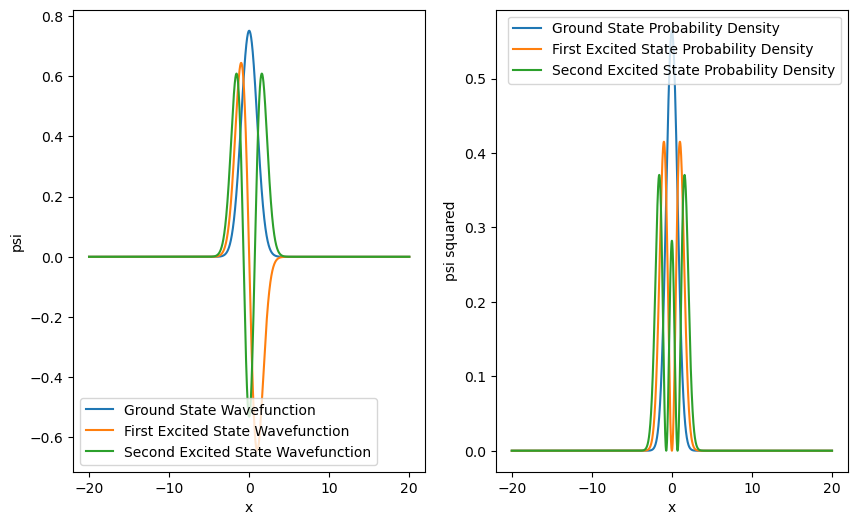

In [424]:
# Plot wavefunctions vs position
x = np.linspace(-L/2, L/2, N)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,2,1)
#ax.plot(x, 0.5*x**2, color='k')
ax.plot(x, psi[:,0], label='Ground State Wavefunction')
ax.plot(x, psi[:,1], label='First Excited State Wavefunction')
ax.plot(x, psi[:,2], label='Second Excited State Wavefunction')
#ax.plot(x, psi[:,3], label='Third Excited State Wavefunction')
#ax.plot(x, psi[:,4], label='Fourth Excited State Wavefunction')
ax.set_ylabel('psi')
ax.set_xlabel('x')
plt.legend()

# Plot probability densities vs position
ax = fig.add_subplot(1,2,2)
ax.plot(x, prob[:,0], label='Ground State Probability Density')
ax.plot(x, prob[:,1], label='First Excited State Probability Density')
ax.plot(x, prob[:,2], label='Second Excited State Probability Density')
#ax.plot(x, prob[:,3], label='Third Excited State Probability Density')
#ax.plot(x, prob[:,4], label='Fourth Excited State Probability Density')
ax.set_ylabel('psi squared')
ax.set_xlabel('x')
plt.legend()
plt.show()

- relative errors in eigenstate energies hint at eigenstates to be used for wavepacket evolution later

In [278]:
n = np.arange(N)
analytical_energies = (n+0.5)*hbar*w

print("--- Simulated vs. Analytical Energies ---")
for i in range(6):
    print(f"n={i}:")
    print(f"  Simulated E = {E[i]:.6f}")
    print(f"  Analytical E= {analytical_energies[i]:.6f}")
    print(f"  Difference  = {abs(E[i] - analytical_energies[i]):.6f}\n")

--- Simulated vs. Analytical Energies ---
n=0:
  Simulated E = 0.500122
  Analytical E= 0.500000
  Difference  = 0.000122

n=1:
  Simulated E = 1.500359
  Analytical E= 1.500000
  Difference  = 0.000359

n=2:
  Simulated E = 2.500585
  Analytical E= 2.500000
  Difference  = 0.000585

n=3:
  Simulated E = 3.500797
  Analytical E= 3.500000
  Difference  = 0.000797

n=4:
  Simulated E = 4.500997
  Analytical E= 4.500000
  Difference  = 0.000997

n=5:
  Simulated E = 5.501185
  Analytical E= 5.500000
  Difference  = 0.001185



### Error Analysis: Truncation vs Roundoff error

- What is truncation error - dominates at large $dx$
- What is Roundoff error - dominates at low $dx$
- Investigate how total error for this method varies with $dx$ - use sin$(x)$ as example function (truncation inherent to method not function)
- Minimise total error - find turning point between where truncation and roundoff error dominate

In [281]:
# numerically sweep dx over 6 orders of magnitude (via N and L)

L_err = 4*np.pi
N_err = np.logspace(1,7, 200)

In [282]:
rel_err = np.zeros(200)

# for each value of dx, find the relative error of the second derivative at x = pi/4 # 

for i in range(200):

    # sweeping dx by fixing L and changing N
    N_i = int(N_err[i])
    dx_err = L_err/N_i
    
    x_err = np.linspace(-L_err/2, L_err/2, N_i)
    s = np.sin(x_err)

    # finite differences central difference method for second derivative
    num_2der = np.zeros(N_i)
    num_2der[1:-1] = (s[2:] + s[:-2] - 2*s[1:-1])/dx_err**2

    # k - closest x value to pi/4
    k = np.argmin(np.abs(x_err - np.pi/4))
    rel_err[i] = np.abs( - np.sin(x_err[k]) - num_2der[k])/np.sin(x_err[k]) # relative error for each dx value

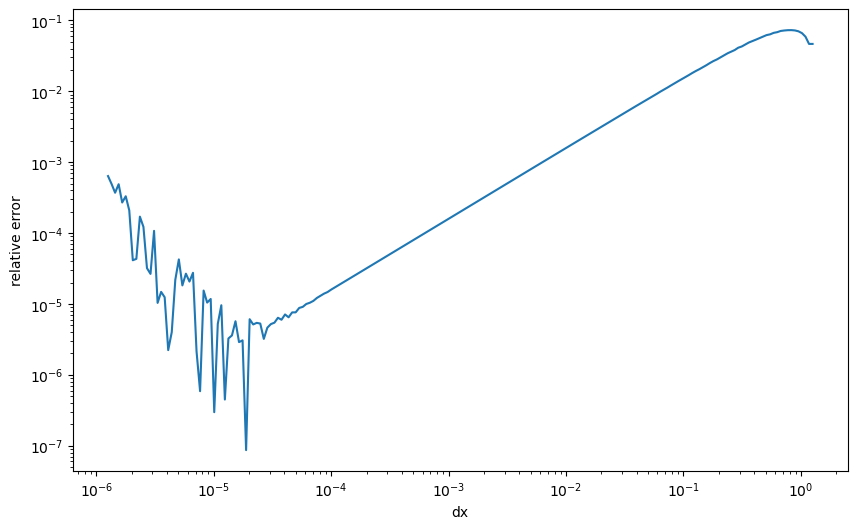

In [283]:
# plot relative error vs dx
dx_err = L_err/N_err

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(dx_err, rel_err)
#ax.axvline(dx_err[163])
ax.set_xlabel('dx')
ax.set_ylabel('relative error')
ax.set_xscale('log')
ax.set_yscale('log')
plt.savefig('trun_round_err')
plt.show()

Locating turning points:
- separate straight line fits to data for $dx$ < $dx_{min}$ (where roundoff error dominates) and for $dx$ > $dx_{min}$  (where truncation error dominates)
- find intersection = turning point
- using least squares method ***

In [285]:
# function for straight line fits
def straight_line(x,m,c):
    y = m*x + c
    return(y)

# fit straight line parameters for dx > dx_min
popt, pcov = curve_fit(straight_line, np.log10(dx_err[20:130]), np.log10(rel_err[20:130]))
m_r = popt[0] 
c_r = popt[1]

# fit straight line parameters for dx < dx_min
popt1, pcov1 = curve_fit(straight_line, np.log10(dx_err[155:199]), np.log10(rel_err[155:199]))
m_l = popt1[0]
c_l = popt1[1] 

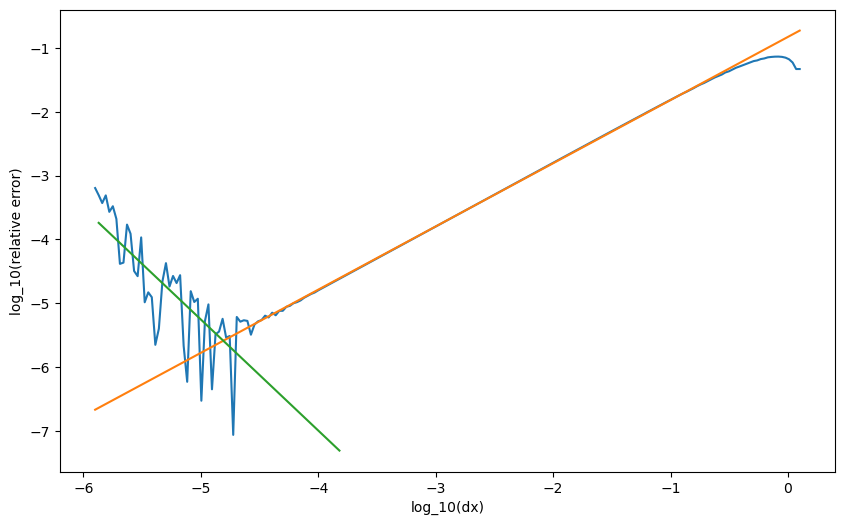

In [286]:
# plot relative error vs dx with straight line fits

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(np.log10(dx_err), np.log10(rel_err))
ax.plot(np.log10(dx_err), m_r*np.log10(dx_err) + c_r)
ax.plot(np.log10(dx_err[130:199]), m_l*np.log10(dx_err[130:199]) + c_l)
ax.set_xlabel(r'log_10(dx)')
ax.set_ylabel(r'log_10(relative error)')
plt.show()

In [287]:
# turning point for optimising round off vs truncation error for this numerical method

p = np.argmin(np.abs((m_r*np.log10(dx_err) + c_r) - (m_l*np.log10(dx_err) + c_l))) # index of dx_min
print(f"The optimal grid spacing for minimising truncation and round-off error when implementing the central differences method for a second derivative is dx = {dx_err[p]:.8f}.")

The optimal grid spacing for minimising truncation and round-off error when implementing the central differences method for a second derivative is dx = 0.00001530.


While minimising both roundoff and truncation error for this numerical method requires $\Delta x \approx 10^{-5}$, a value of $\Delta x = 10^{-2}$ is used. This is because $\Delta x < 10^{-2}$ makes the programs take too long to run.
- Truncation error dominates (roundoff error not significant in comparison ~$10^{-12}$)
- Second order method $\rightarrow$ truncation varies as $O(\Delta x)^2$
- Hence eigenvalues have errors of order greater than/equal to $(\Delta x)^2 = 10^{-4}$ for first few eigenstates

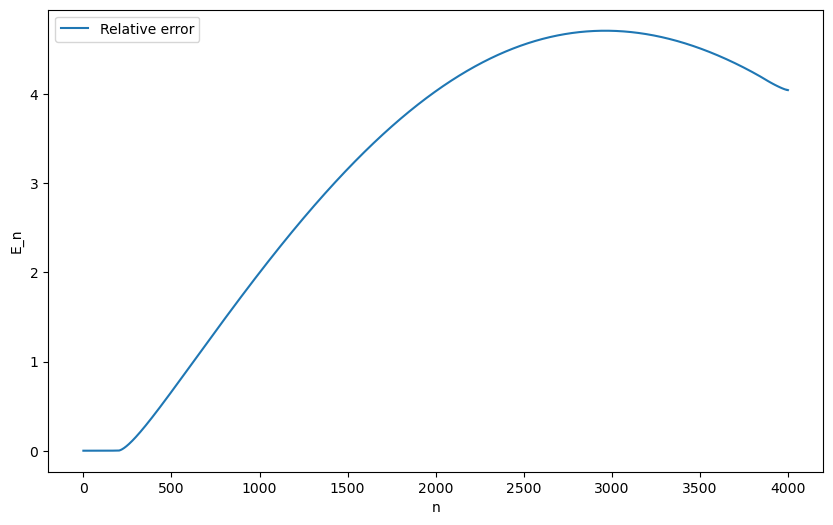

In [289]:
# plot |(numerical E_n) - (analytic E_n)| vs n
E_error = np.abs(E - (n + 0.5)*w*hbar)/ ((n + 0.5)*w*hbar)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
#ax.plot(n, analytical_energies, label='analytical energies')
#ax.plot(n, E, label='numerical energies')
ax.plot(n, np.abs(E-(n+0.5))/(n+0.5), label = 'Relative error')
ax.set_xlabel('n')
ax.set_ylabel('E_n')
plt.legend()
plt.savefig('E_n')
plt.show()

- need to do some sanity checks here

# Time Evolution of Gaussian Wavepacket in Harmonic Potential

- Gaussian wavepacket - equation
- Describe known behaviour in harmonic potential - no dispersion etc
- Explain what this section shows - calculates wavepacket and time evolution, justifies use of first 80 eigenstates only, explains errors incurred when using all eigenstates and subsequent turning point error. 

In [293]:
# define parameters for intitial position, initial momentum and spread of wavepacket

x_0 = 1
k_0 = 10
sigma = 1

In [294]:
# function for initial Gaussian wavepacket

def gaussian_wavepacket(x):
    return((1/(2*np.pi*sigma**2)**0.25)*np.exp(-((x-x_0)**2)/4*sigma**2)*np.exp(1j*k_0*(x-x_0)))

In [295]:
# gaussian wavepacket at time t = 0

Psi_initial = np.zeros(N, dtype=complex)
for k in range(N):
    Psi_initial[k] = gaussian_wavepacket(x[k])

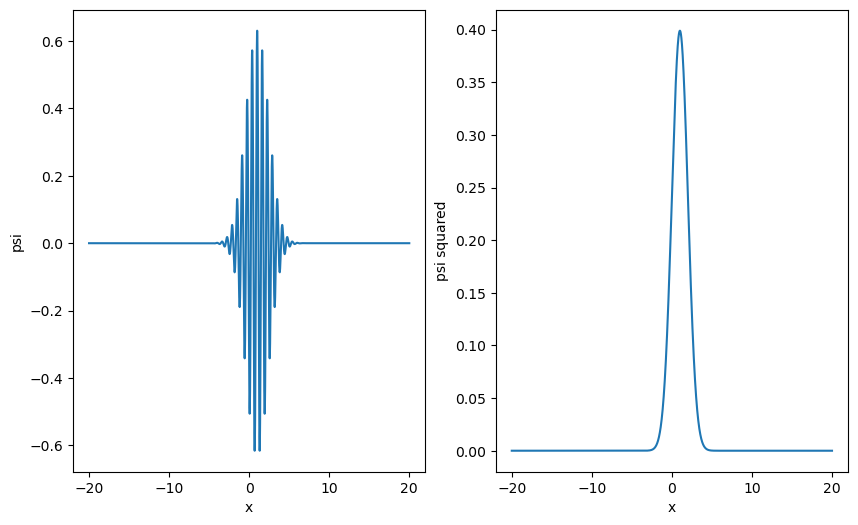

In [296]:
# plot initial Gaussian wavepacket and probability density
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,2,1)
ax.plot(x, Psi_initial.real)
ax.set_ylabel('psi')
ax.set_xlabel('x')

ax1 = fig.add_subplot(1,2,2)
ax1.plot(x, np.abs(Psi_initial)**2)
ax1.set_ylabel('psi squared')
ax1.set_xlabel('x')
plt.show()

In [297]:
# calculating coefficients c_n to decompose wavepacket into system eigenstates 

n_max = 80 # max number of eigenstates used - minimise error due to L

c_n = np.zeros(n_max, dtype=complex)

# calculate coefficients
for b in range(n_max):
    for a in range(N):
        c_n[b] += psi[a,b]*Psi_initial[a]*dx

0.9997499885270947


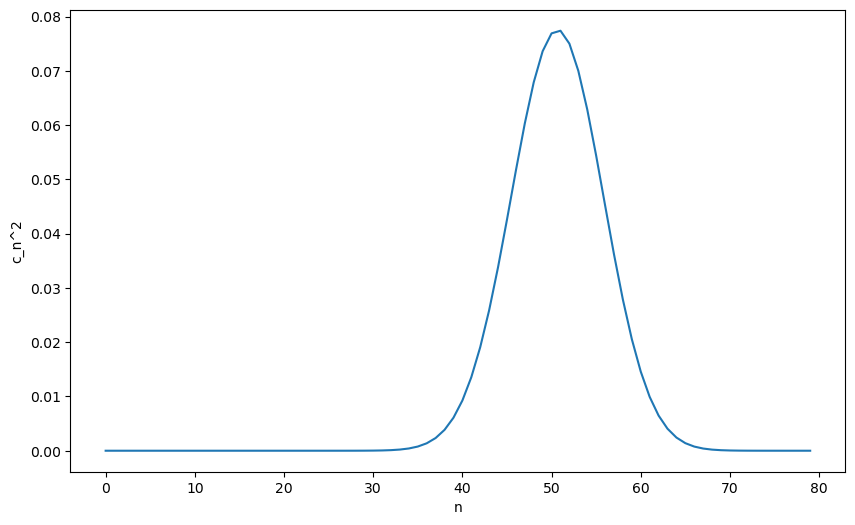

In [298]:
print(sum(np.abs(c_n)**2))

n = np.arange(n_max)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(n, np.abs(c_n)**2)
ax.set_xlabel('n')
ax.set_ylabel('c_n^2')
plt.show()

In [299]:
# discretise time step t 
M = 201
t = np.linspace(0,20,M)

# initialise Psi_xt
Psi_xt = np.zeros((N,M), dtype=complex)

# use matrix multiplication to find time evolution from Psi_initial
for k in range(M):
    c_nk = c_n*np.exp(-1j*E[:n_max]*t[k]/hbar)
    Psi_xt[:,k] = np.matmul(psi[:,:n_max], c_nk)

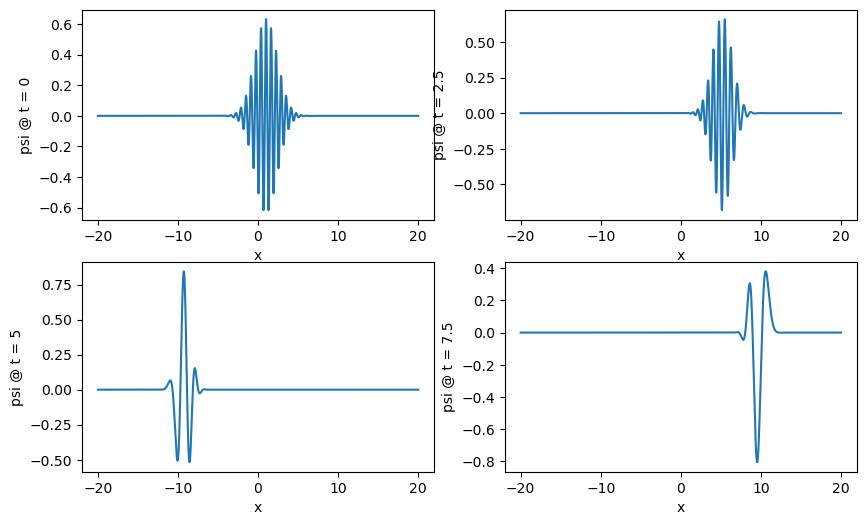

In [300]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(2,2,1)
ax.plot(x, Psi_xt[:,0].real)
ax.set_ylabel('psi @ t = 0')
ax.set_xlabel('x')

ax1 = fig.add_subplot(2,2,2)
ax1.plot(x, Psi_xt[:,25].real)
ax1.set_ylabel('psi @ t = 2.5')
ax1.set_xlabel('x')

ax2 = fig.add_subplot(2,2,3)
ax2.plot(x, Psi_xt[:,50].real)
ax2.set_ylabel('psi @ t = 5')
ax2.set_xlabel('x')

ax3 = fig.add_subplot(2,2,4)
ax3.plot(x, Psi_xt[:,75].real)
ax3.set_ylabel('psi @ t = 7.5')
ax3.set_xlabel('x')

plt.show()

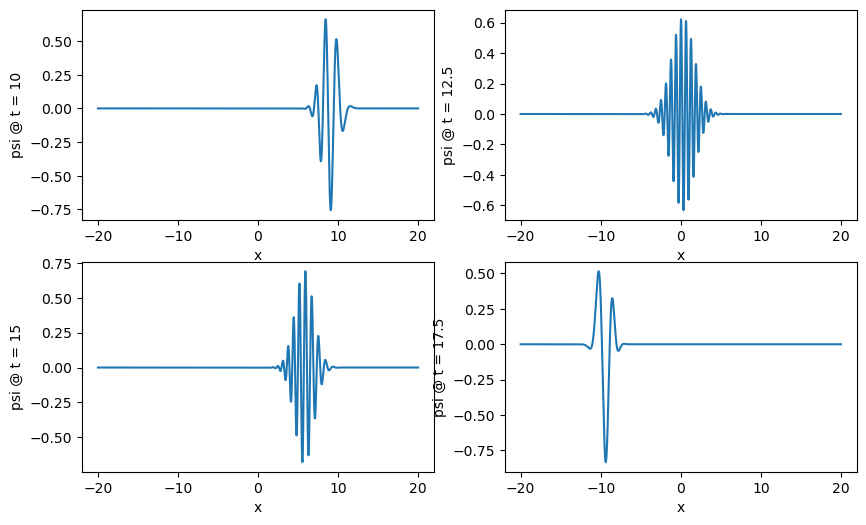

In [301]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(2,2,1)
ax.plot(x, Psi_xt[:,10].real)
ax.set_ylabel('psi @ t = 10')
ax.set_xlabel('x')

ax1 = fig.add_subplot(2,2,2)
ax1.plot(x, Psi_xt[:,125].real)
ax1.set_ylabel('psi @ t = 12.5')
ax1.set_xlabel('x')

ax2 = fig.add_subplot(2,2,3)
ax2.plot(x, Psi_xt[:,150].real)
ax2.set_ylabel('psi @ t = 15')
ax2.set_xlabel('x')

ax3 = fig.add_subplot(2,2,4)
ax3.plot(x, Psi_xt[:,175].real)
ax3.set_ylabel('psi @ t = 17.5')
ax3.set_xlabel('x')

plt.show()

### Error analysis: Domain Turning point error

- Gaussian wavepacket in harmonic potential - no dispersion expected
- initially used all N eigenstates - this gave a dispersing wavepacket for $t > 10$
- could be due to errors in eigenstates (which increases with n) due to width of domain used
- Plot $c_n^2$ values to determine which eigenstates make biggest contribution to initial wavepacket

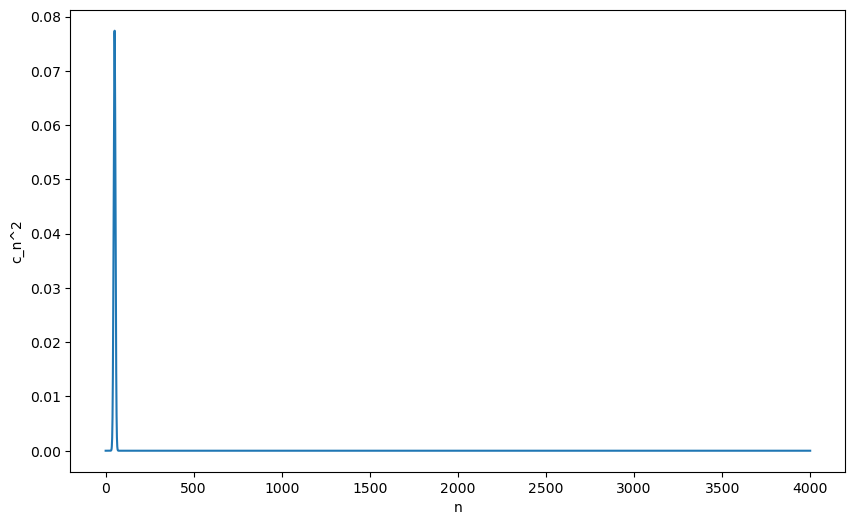

In [304]:
# plot c_n^2 where all eigenstates used 
n_all_v = np.arange(N)

cn_all_v = np.zeros(N, dtype=complex)

# calculate coefficients
for b in range(N):
    for a in range(N):
        cn_all_v[b] += psi[a,b]*Psi_initial[a]*dx

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(n_all_v, np.abs(cn_all_v)**2) 
ax.set_xlabel('n')
ax.set_ylabel('c_n^2')
plt.show()

- Most significant contributions made by eigenstates for n < 100
- want to understand how, for fixed $\Delta x = 0.01$ as limited by feasible runtime, the relative error of the first 100 eigenstates changes with domain width $L$

- Justify choice using classical prediction of turning point $x_{tp} \approx \sqrt {2n + 1}$

In [307]:
# vary L via N: L = N*dx
N_tp = np.linspace(100,4000, 51).astype(int) 

# exact eigenvalues for first 100 eigenstates
n = np.arange(100)
E_analytical = (n+0.5)*hbar*w

# stores relative error for 1st 100 eigenstates for values of N
E_rel_err = np.zeros((100,len(N_tp)))

In [308]:
for j in range(len(N_tp)): # takes ~170s to run
    H_N = Hamiltonian(N_tp[j])
    E_N, v = eigh(H_N)

    # select only the first 100 eigenvalues
    E_100 = E_N[0:100]

    # calculate relative error for 1st 100 eigenstates for given N
    E_rel_err[:,j] = np.abs(E_100 - E_analytical)/E_analytical

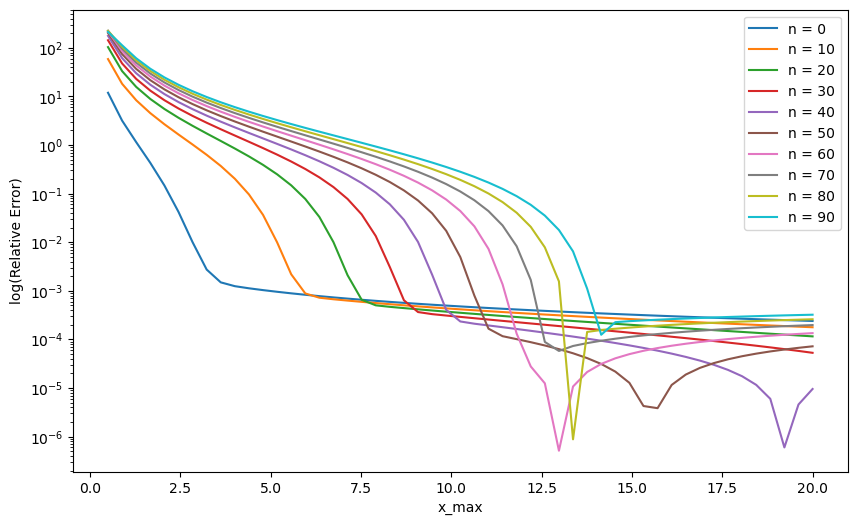

In [309]:
x_max = N_tp*dx/2

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
for b in range(10):
    ax.plot(x_max, E_rel_err[10*b+1,:], label=f'n = {10*b}')
ax.set_xlabel('x_max')
ax.set_ylabel('log(Relative Error)')
ax.set_yscale('log')
plt.legend()
plt.savefig('turning_point_err.png')
plt.show()

- comment on dips below truncation error minimum - due to use of absolute value?

## Position: expectation and uncertainty

The following determines the expectation values and uncertainties in the position and momentum for the Gaussian wavepacket in a harmonic potential, and confirms that the Heinsenburg Uncertainty Principle is satisfied for all time.

- The uncertainty in observable $a$ with corresponding operator $\hat{A}$ for wavefunction $\psi$ is $\Delta a = \sqrt{\langle a^2 \rangle - \langle a \rangle^2}$.
- The expectation value of $a$ is $\langle a \rangle = \langle \psi | \hat{A} | \psi \rangle$.
- The expectation value of $a^2$ is $\langle a^2 \rangle = \langle \psi | \hat{A}^2 | \psi \rangle$
- In position basis, $\hat{X} = x$

In [314]:
# <x> as function of t
x_exp_t = np.zeros(M)

for j in range(M):
    x_exp_t[j] = sum((np.abs(Psi_xt[:,j])**2)*x*dx)

# <x^2> as function of t
x2_exp_t = np.zeros(M)

for j in range(M):
    x2_exp_t[j] = sum((np.abs(Psi_xt[:,j])**2)*(x**2)*dx)

# uncertainty in x as function of t
x_unc_t = np.sqrt(x2_exp_t - x_exp_t**2)

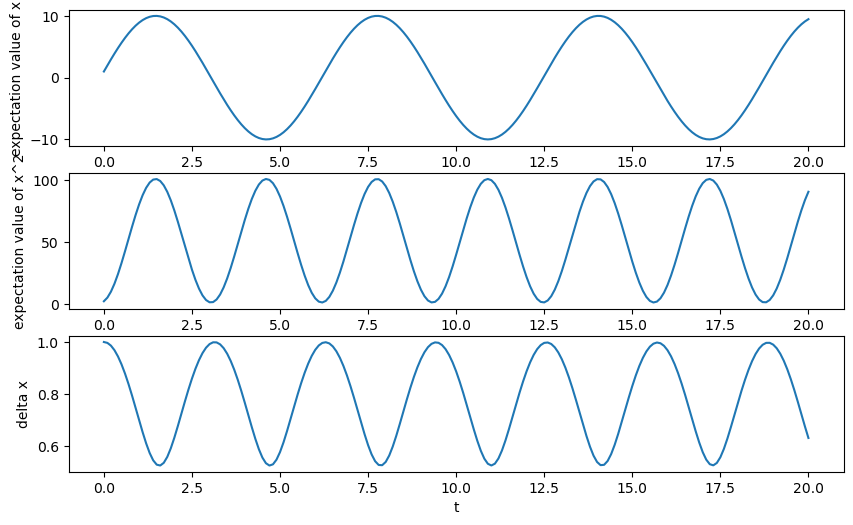

In [315]:
# plots for <x>, <x^2> and delta x respectively as functions of time
fig = plt.figure(figsize=(10,6))

ax1 = fig.add_subplot(3,1,1)
ax1.plot(t, x_exp_t)
ax1.set_xlabel('t')
ax1.set_ylabel('expectation value of x')

ax2 = fig.add_subplot(3,1,2)
ax2.plot(t, x2_exp_t)
ax2.set_xlabel('t')
ax2.set_ylabel('expectation value of x^2')

ax3 = fig.add_subplot(3,1,3)
ax3.plot(t, x_unc_t)
ax3.set_xlabel('t')
ax3.set_ylabel('delta x')
plt.show()

# Momentum: Expectation and Uncertainty

- In position basis, the momentum operator is $\hat{P} = -i \hbar \frac{d}{dx}$ and $\hat{P}^2 = - \hbar^2 \frac{d^2}{dx^2}$.
- To approximate the first derivative for $\hat{P}$, the central differences method is used as before. This remains a second order numerical method.
- The second derivative for $\hat{P}^2$ is approximated using the same central differences approach as for the original Hamiltonian

In [318]:
ddx = np.diag(np.ones(N-1),1)+np.diag(-np.ones(N-1),-1) # matrix for first x derivative

# <p> as function of t
p_exp_t = np.zeros(M, dtype=complex)
for m in range(M):
    p_exp_t[m] = (-1j*hbar/2)*np.matmul(np.conj(Psi_xt[:,m]), np.matmul(ddx, Psi_xt[:,m]))

# <p^2> as function of t
p2_exp_t = np.zeros(M, dtype=complex)
for n in range(M):
    p2_exp_t[n] = (-1/dx)*np.matmul(np.conj(Psi_xt[:,n]), np.matmul(T1, Psi_xt[:,n])) # T1 is the matrix for the second x derivative as defined in the Hamiltonian function

# uncertainty in p as function of t
p_unc_t = np.sqrt(p2_exp_t - p_exp_t**2)

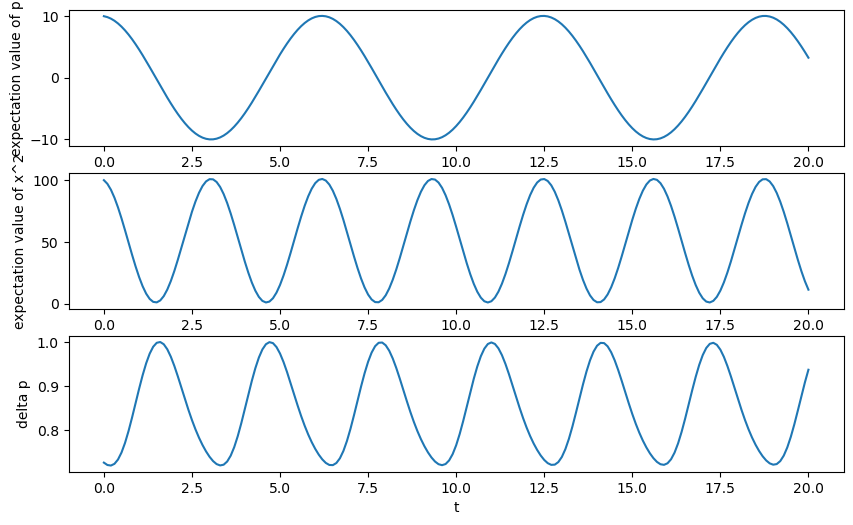

In [319]:
# plots for <p>, <p^2> and delta p respectively as functions of time
fig = plt.figure(figsize=(10,6))

ax1 = fig.add_subplot(3,1,1)
ax1.plot(t, p_exp_t.real)
ax1.set_xlabel('t')
ax1.set_ylabel('expectation value of p')

ax2 = fig.add_subplot(3,1,2)
ax2.plot(t, p2_exp_t)
ax2.set_xlabel('t')
ax2.set_ylabel('expectation value of x^2')

ax3 = fig.add_subplot(3,1,3)
ax3.plot(t, p_unc_t)
ax3.set_xlabel('t')
ax3.set_ylabel('delta p')
plt.show()

- The uncertainty principle 

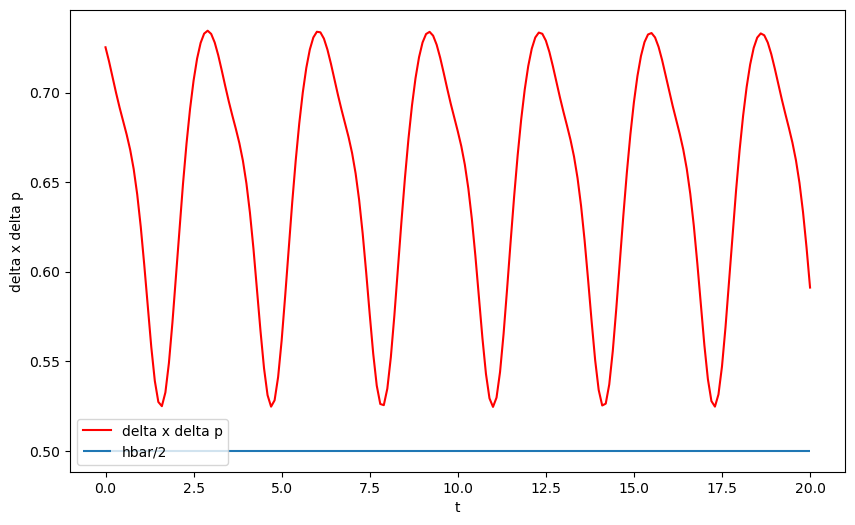

In [321]:
 # check satisfies uncertainty principle

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(t, x_unc_t*p_unc_t, color='r',label='delta x delta p')
ax.hlines(hbar/2, t[0], t[200], label='hbar/2')
ax.set_xlabel('t')
ax.set_ylabel('delta x delta p')
plt.legend()
plt.show()